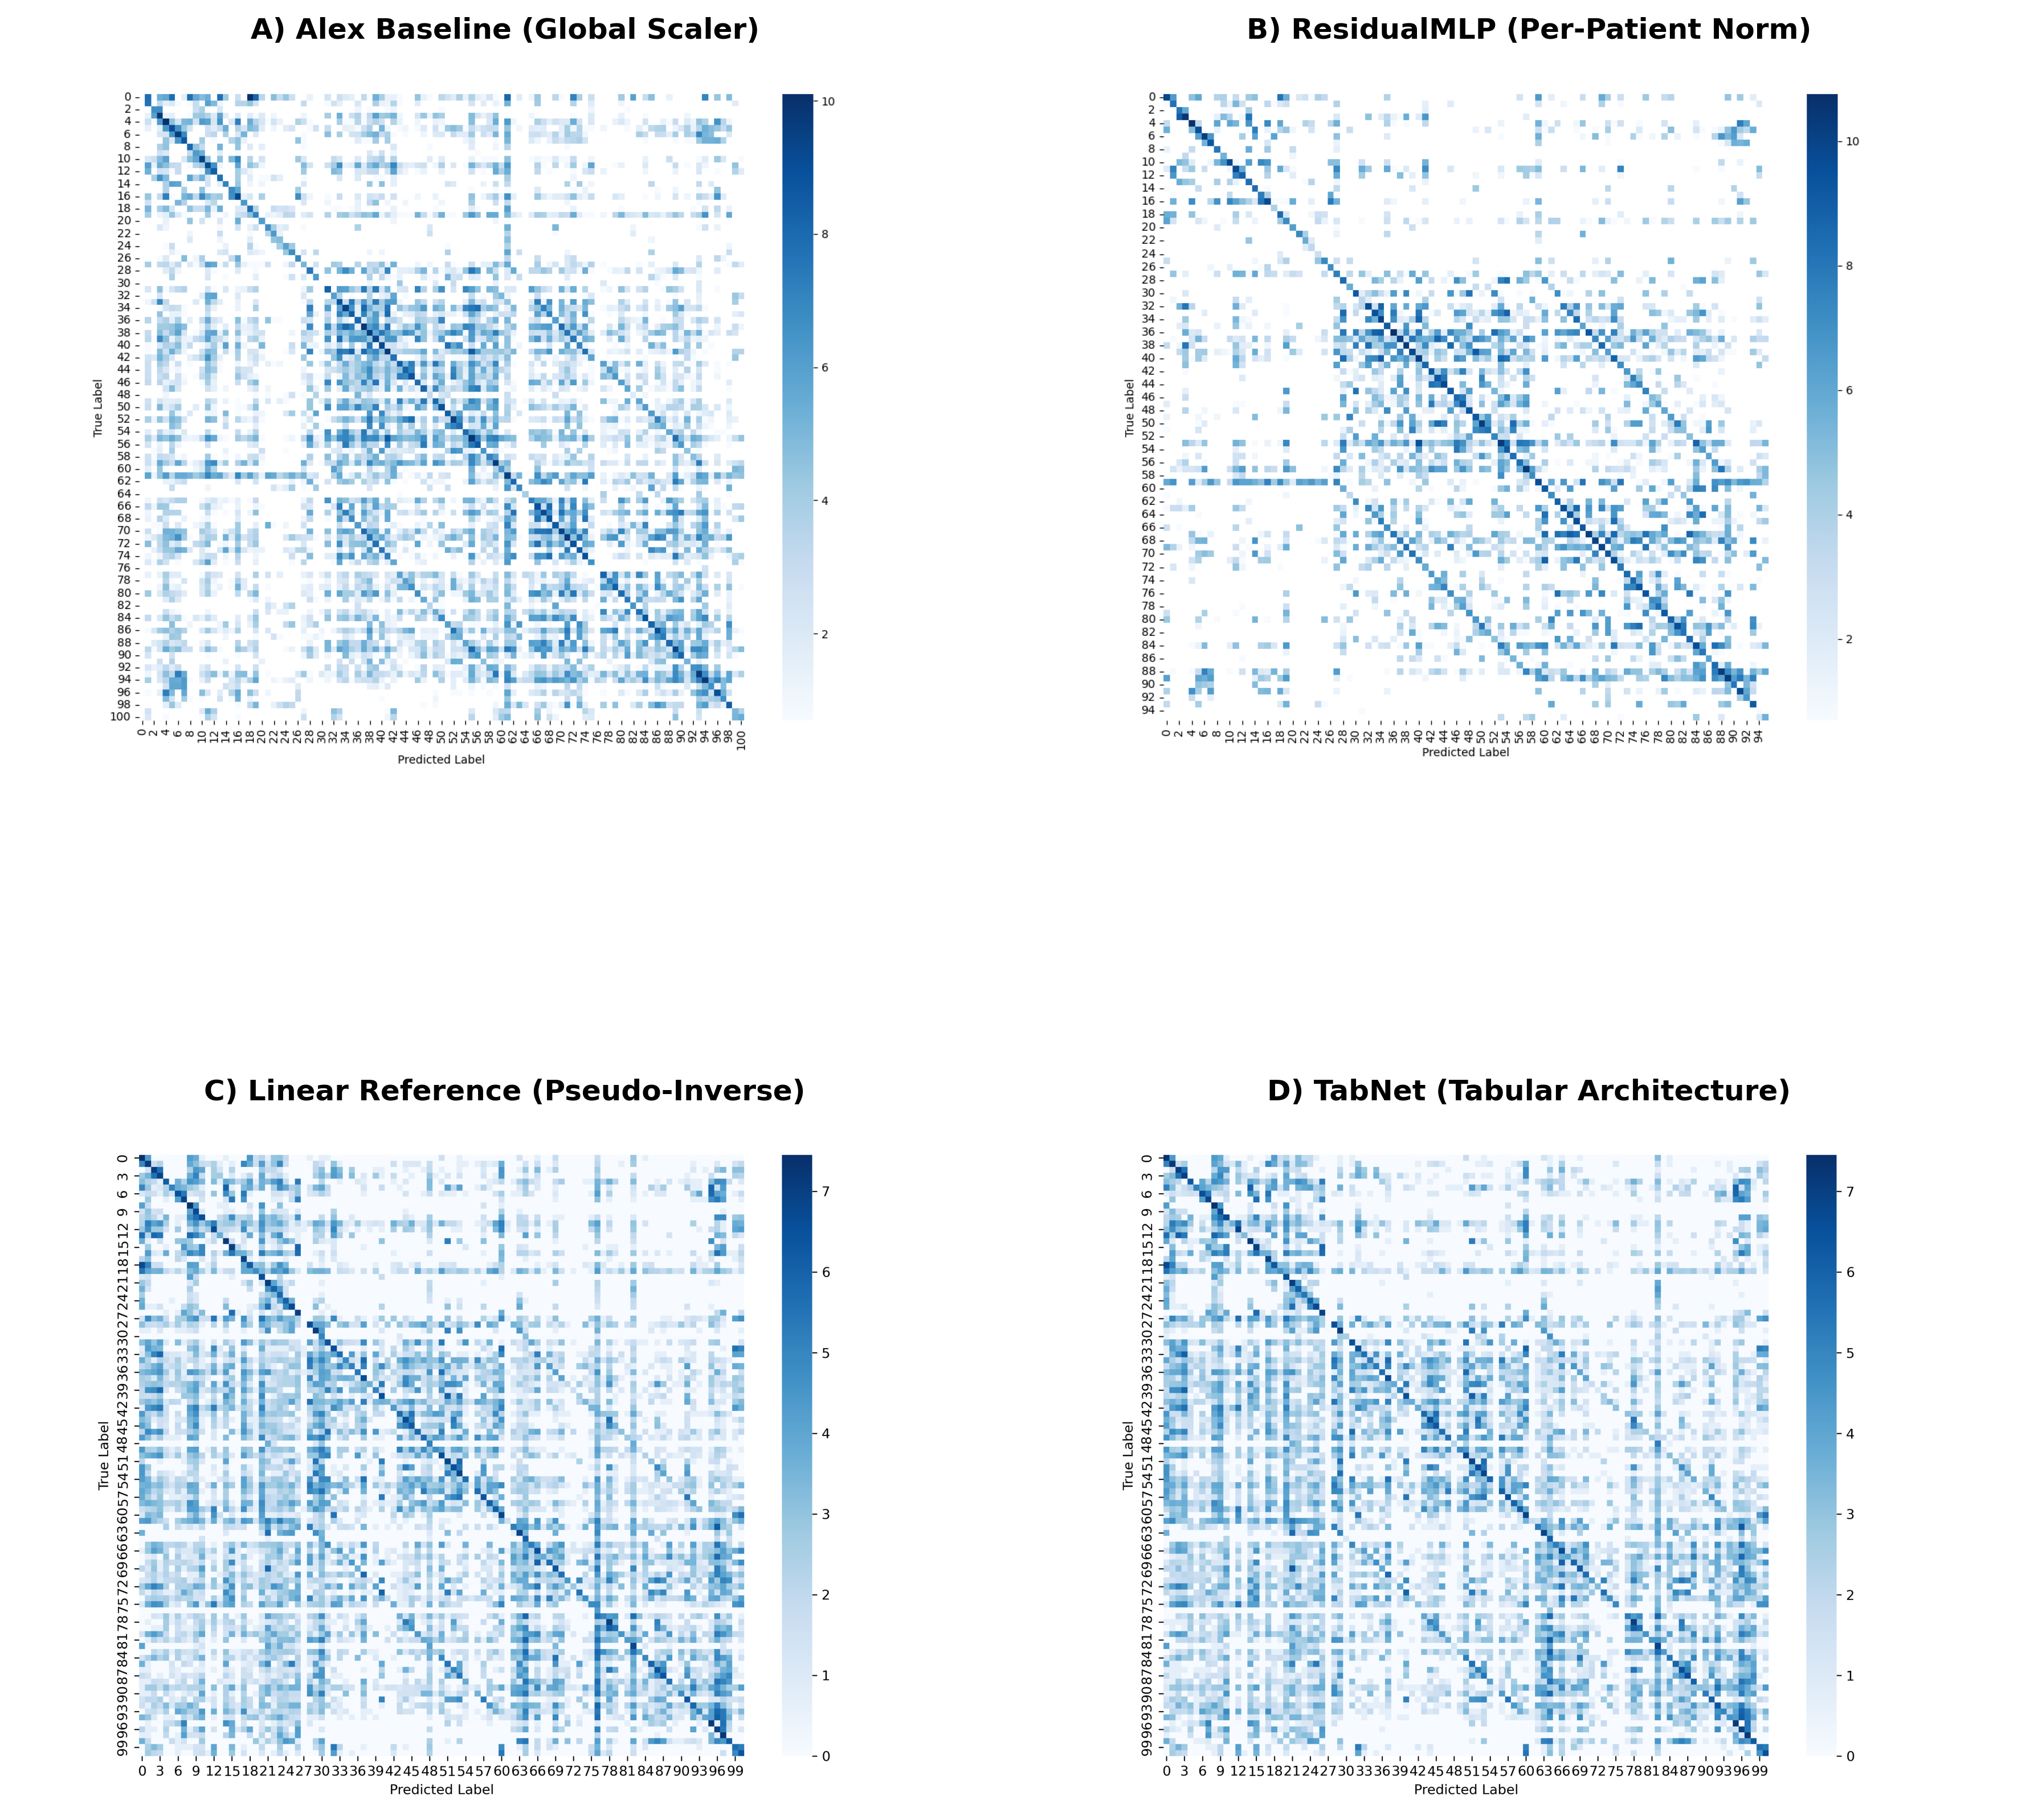

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 文件路径 (根据您上传的文件名)
files = {
    'tl': 'baseline_val_confusion_matrix.png',
    'tr': 'ResMLPtest_confusion_matrix(1).png',
    'bl': '伪逆矩阵confusion_matrix_val.png',
    'br': '违逆作为tabnetconfusion_matrix_val.png'
}

titles = {
    'tl': 'A) Alex Baseline (Global Scaler)',
    'tr': 'B) ResidualMLP (Per-Patient Norm)',
    'bl': 'C) Linear Reference (Pseudo-Inverse)',
    'br': 'D) TabNet (Tabular Architecture)'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=300)
axes = axes.flatten()

order = ['tl', 'tr', 'bl', 'br']

for i, key in enumerate(order):
    img = mpimg.imread(files[key])
    
    # 简单的裁切: 去掉图片自带的标题(顶部)和多余白边
    # 假设标题在顶部 10% 左右
    h, w, _ = img.shape
    crop_top = int(h * 0.08) 
    crop_bottom = int(h * 0.95)
    img_cropped = img[crop_top:crop_bottom, :, :]
    
    axes[i].imshow(img_cropped)
    axes[i].set_title(titles[key], fontsize=12, fontweight='bold', pad=10)
    axes[i].axis('off') # 关闭坐标轴，因为原图里已经有了

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.1) # 减小间距
plt.savefig('fig3_3_composite.png', bbox_inches='tight')
plt.show()

Figure generated: fig3_3_row_composite.png


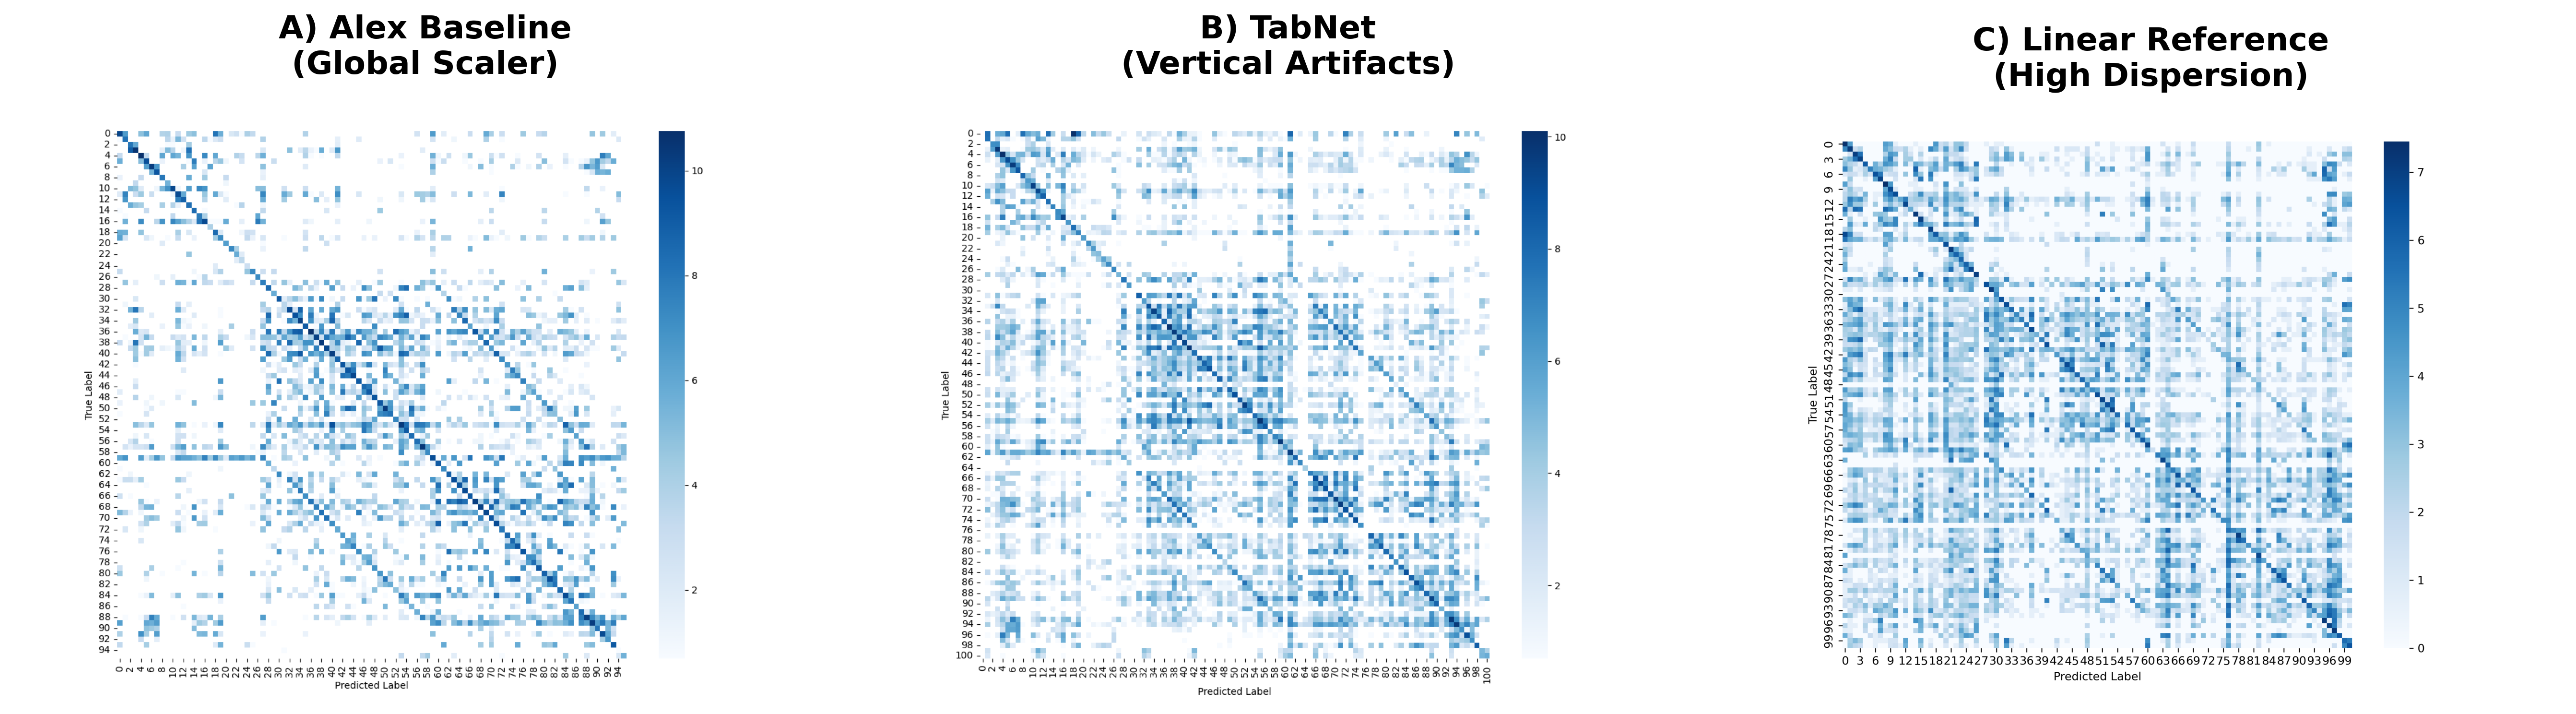

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


# ==========================================
# 1. 文件配置 (左 -> 中 -> 右)
# ==========================================
files = {
    'left':   'ResMLPtest_confusion_matrix(1).png',          # Baseline
    'middle': 'baseline_val_confusion_matrix.png',     # TabNet
    'right':  '伪逆矩阵confusion_matrix_val.png'            # Linear
}

titles = {
    'left':   'A) Alex Baseline\n(Global Scaler)',
    'middle': 'B) TabNet\n(Vertical Artifacts)',
    'right':  'C) Linear Reference\n(High Dispersion)'
}

# ==========================================
# 2. 绘图设置 (1行3列)
# ==========================================
# figsize=(18, 6) 保证了每个子图足够大且清晰
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

order = ['left', 'middle', 'right']

for i, key in enumerate(order):
    try:
        img = mpimg.imread(files[key])
        
        # 裁切逻辑 (保持不变)
        h, w, _ = img.shape
        crop_top = int(h * 0.08) 
        crop_bottom = int(h * 0.95)
        img_cropped = img[crop_top:crop_bottom, :, :]
        
        axes[i].imshow(img_cropped)
        axes[i].set_title(titles[key], fontsize=16, fontweight='bold', pad=15)
        axes[i].axis('off')
        
    except FileNotFoundError:
        print(f"Error: File {files[key]} not found. Please check filename.")
        axes[i].text(0.5, 0.5, "Image Not Found", ha='center', va='center')
        axes[i].axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=0.05) # 减小图片之间的水平间距
plt.savefig('fig3_3_row_composite.png', bbox_inches='tight')
print("Figure generated: fig3_3_row_composite.png")
plt.show()